In [ ]:
#@title Copyright 2023 Google LLC. Double-click here for license information.
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Colabs

Machine Learning Crash Course uses Colaboratories (Colabs) for all programming exercises. Colab is Google's implementation of [Jupyter Notebook](https://jupyter.org/). For more information about Colabs and how to use them, go to [Welcome to Colaboratory](https://research.google.com/colaboratory).

# Linear Regression
In this Colab you will use a real dataset to train a model to predict the fare of a taxi ride in Chicago, Illinois.

## Learning Objectives
After completing this Colab, you'll be able to:

  * Read a .csv file into a [pandas](https://developers.google.com/machine-learning/glossary/#pandas) DataFrame.
  * Explore a [dataset](https://developers.google.com/machine-learning/glossary/#data_set) with Python visualization libraries.
  * Experiment with different [features](https://developers.google.com/machine-learning/glossary/#feature) to build a linear regression model.
  * Tune the model's [hyperparameters](https://developers.google.com/machine-learning/glossary/#hyperparameter).
  * Compare training runs using [root mean squared error](https://developers.google.com/machine-learning/glossary/#root-mean-squared-error-rmse) and [loss curves](https://developers.google.com/machine-learning/glossary/#loss-curve).

## Dataset Description
The [dataset for this exercise](https://storage.mtls.cloud.google.com/mlcc-nextgen-internal/chicago_taxi_train.csv) is derived from the [City of Chicago Taxi Trips dataset](https://data.cityofchicago.org/Transportation/Taxi-Trips/wrvz-psew). The data for this exercise is a subset of the Taxi Trips data, and focuses on a two-day period in May of 2022.

# Part 1 - Setup Exercise


---



## Load required modules

This exercise depends on several Python libraries to help with data manipulation, machine learning tasks, and data visualization.

**Instructions**
1. Run the **Install required libraries** code cell (below).
1. Run the **Load dependencies** code cell (below).

In [ ]:
#@title Install required libraries

!pip install numpy~=2.0.0
!pip install matplotlib~=3.10.0
!pip install pandas~=2.2.0
!pip install tensorflow~=2.18.0
!pip install keras~=3.8.0
!pip install yahoo_fin yfinance

print('\n\nAll requirements successfully installed.')



All requirements successfully installed.


In [ ]:
#@title Code - Load dependencies

#general
import io

# data
import numpy as np
import pandas as pd
import yfinance as yf

# machine learning
import keras

# data visualization
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import seaborn as sns

## Load the dataset


The following code cell loads the dataset and creates a pandas DataFrame.

You can think of a DataFrame like a spreadsheet with rows and columns. The rows represent individual data examples, and the columns represent the attributes associated with each example.

In [ ]:
import yfinance as yf

# Fetch Bitcoin data from Yahoo Finance
btc = yf.Ticker("BTC-USD")
btc_price = btc.history(period="1d")["Close"].iloc[-1]

print(f"Current Bitcoin Price: ${btc_price:.2f}")

Current Bitcoin Price: $84048.62


## Update the dataframe

The following code cell updates the DataFrame to use only specific columns from the dataset.

Notice that that output shows just a sample of the dataset, but there should be enough information for you to identify the features associated with the dataset, and have a look at the actual data for a few examples.

In [ ]:
# #@title Code - Read dataset

# Updates dataframe to use specific columns.
training_df = btc.history(period="7d", interval="15m")[['High', 'Low', 'Close', 'Volume']]
training_df['Datetime'] = training_df.index

print('Read dataset completed successfully.')
print('Total number of rows: {0}\n\n'.format(len(training_df.index)))
training_df.head(200)

# import yfinance as yf

# # Fetch historical 15-minute interval data for Bitcoin
# btc = yf.Ticker("BTC-USD")
# btc_data = btc.history(period="7d", interval="15m")  # Change period as needed

# # Display the historical data
# print(btc_data)

Read dataset completed successfully.
Total number of rows: 664




,High,Low,Close,Volume,Datetime
Datetime,,,,,
2025-03-16 00:00:00+00:00,84356.492188,84277.375000,84345.625000,19313664,2025-03-16 00:00:00+00:00
2025-03-16 00:15:00+00:00,84333.703125,84271.828125,84277.703125,61621248,2025-03-16 00:15:00+00:00
2025-03-16 00:30:00+00:00,84310.015625,84240.281250,84306.398438,0,2025-03-16 00:30:00+00:00
2025-03-16 00:45:00+00:00,84295.406250,84245.773438,84268.406250,88287232,2025-03-16 00:45:00+00:00
2025-03-16 01:00:00+00:00,84274.023438,84206.257812,84206.257812,13499392,2025-03-16 01:00:00+00:00
...,...,...,...,...,...
2025-03-18 00:45:00+00:00,83786.703125,83729.796875,83786.703125,151015424,2025-03-18 00:45:00+00:00
2025-03-18 01:00:00+00:00,83902.390625,83634.179688,83634.179688,22874112,2025-03-18 01:00:00+00:00
2025-03-18 01:15:00+00:00,83621.656250,83268.015625,83381.148438,197347328,2025-03-18 01:15:00+00:00


# Part 2 - Dataset Exploration


---



## View dataset statistics

A large part of most machine learning projects is getting to know your data. In this step, you will use the ``DataFrame.describe`` method to view descriptive statistics about the dataset and answer some important questions about the data.

**Instructions**
1. Run the **View dataset statistics** code cell.
1. Inspect the output and answer these questions:
  * What is the maximum fare?
  * What is the mean distance across all trips?
  * How many cab companies are in the dataset?
  * What is the most frequent payment type?
  * Are any features missing data?
1. Run the code **View answers to dataset statistics** code cell to check your answers.


You might be wondering why there are groups of `NaN` (not a number) values listed in the output. When working with data in Python, you may see this value if the result of a calculation can not be computed or if there is missing information. For example, in the taxi dataset `PAYMENT_TYPE` and `COMPANY` are non-numeric, categorical features; numeric information such as mean and max do not make sense for categorical features so the output displays `NaN`.

In [ ]:
#@title Code - View dataset statistics

print('Total number of rows: {0}\n\n'.format(len(training_df.index)))
training_df.describe(include='all')

Total number of rows: 664




,High,Low,Close,Volume,Datetime
count,664.000000,664.000000,664.000000,6.640000e+02,664
mean,83989.668404,83804.008260,83896.905591,2.440752e+08,2025-03-19 10:52:30+00:00
min,81418.906250,81195.476562,81241.859375,0.000000e+00,2025-03-16 00:00:00+00:00
25%,83301.666016,83134.173828,83226.238281,3.587379e+07,2025-03-17 17:26:15+00:00
50%,84088.789062,83910.609375,84012.339844,1.310157e+08,2025-03-19 10:52:30+00:00
75%,84361.656250,84251.132812,84294.277344,3.125709e+08,2025-03-21 04:18:45+00:00
max,87442.195312,86870.867188,87338.179688,2.307009e+09,2025-03-22 21:45:00+00:00
std,1020.600527,1020.247741,1021.795977,3.296607e+08,NaN


In [ ]:
#@title Double-click or run to view answers about dataset statistics

answer = '''
What is the maximum fare? 				              Answer: $159.25
What is the mean distance across all trips? 		Answer: 8.2895 miles
How many cab companies are in the dataset? 		  Answer: 31
What is the most frequent payment type? 		    Answer: Credit Card
Are any features missing data? 				          Answer: No
'''

# You should be able to find the answers to the questions about the dataset
# by inspecting the table output after running the DataFrame describe method.
#
# Run this code cell to verify your answers.

# What is the maximum fare?
max_fare = training_df['FARE'].max()
print("What is the maximum fare? \t\t\t\tAnswer: ${fare:.2f}".format(fare = max_fare))

# What is the mean distance across all trips?
mean_distance = training_df['TRIP_MILES'].mean()
print("What is the mean distance across all trips? \t\tAnswer: {mean:.4f} miles".format(mean = mean_distance))

# How many cab companies are in the dataset?
num_unique_companies =  training_df['COMPANY'].nunique()
print("How many cab companies are in the dataset? \t\tAnswer: {number}".format(number = num_unique_companies))

# What is the most frequent payment type?
most_freq_payment_type = training_df['PAYMENT_TYPE'].value_counts().idxmax()
print("What is the most frequent payment type? \t\tAnswer: {type}".format(type = most_freq_payment_type))

# Are any features missing data?
missing_values = training_df.isnull().sum().sum()
print("Are any features missing data? \t\t\t\tAnswer:", "No" if missing_values == 0 else "Yes")


KeyError: 'FARE'

## Generate a correlation matrix

An important part of machine learning is determining which [features](https://developers.google.com/machine-learning/glossary/#feature) correlate with the [label](https://developers.google.com/machine-learning/glossary/#label). If you have ever taken a taxi ride before, your experience is probably telling you that the fare is typically associated with the distance traveled and the duration of the trip. But, is there a way for you to learn more about how well these features correlate to the fare (label)?

In this step, you will use a **correlation matrix** to identify features whose values correlate well with the label. Correlation values have the following meanings:

  * **`1.0`**: perfect positive correlation; that is, when one attribute rises, the other attribute rises.
  * **`-1.0`**: perfect negative correlation; that is, when one attribute rises, the other attribute falls.
  * **`0.0`**: no correlation; the two columns [are not linearly related](https://en.wikipedia.org/wiki/Correlation_and_dependence#/media/File:Correlation_examples2.svg).

In general, the higher the absolute value of a correlation value, the greater its predictive power.

**Instructions**

1. Inspect the code in the **View correlation matrix** code cell.
1. Run the **View correlation matrix** code cell and inspect the output.
1. **Check your understanding** by answering these questions:
  * Which feature correlates most strongly to the label FARE?
  * Which feature correlates least strongly to the label FARE?


In [ ]:
#@title Code - View correlation matrix
training_df.corr(numeric_only = True)

,High,Low,Close,Volume
High,1.000000,0.990001,0.993901,0.263829
Low,0.990001,1.000000,0.992914,0.209768
Close,0.993901,0.992914,1.000000,0.238480
Volume,0.263829,0.209768,0.238480,1.000000


In [ ]:
#@title Double-click to view answers about the correlation matrix

# Which feature correlates most strongly to the label FARE?
# ---------------------------------------------------------
answer = '''
The feature with the strongest correlation to the FARE is TRIP_MILES.
As you might expect, TRIP_MILES looks like a good feature to start with to train
the model. Also, notice that the feature TRIP_SECONDS has a strong correlation
with fare too.
'''
print(answer)


# Which feature correlates least strongly to the label FARE?
# -----------------------------------------------------------
answer = '''The feature with the weakest correlation to the FARE is TIP_RATE.'''
print(answer)


The feature with the strongest correlation to the FARE is TRIP_MILES.
As you might expect, TRIP_MILES looks like a good feature to start with to train
the model. Also, notice that the feature TRIP_SECONDS has a strong correlation
with fare too.

The feature with the weakest correlation to the FARE is TIP_RATE.


## Visualize relationships in dataset

Sometimes it is helpful to visualize relationships between features in a dataset; one way to do this is with a pair plot. A **pair plot** generates a grid of pairwise plots to visualize the relationship of each feature with all other features all in one place.

**Instructions**
1. Run the **View pair plot** code cell.

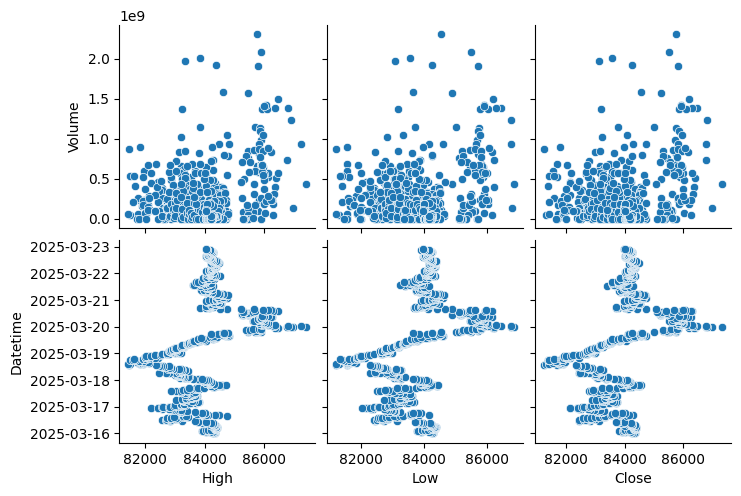

In [ ]:
#@title Code - View pairplot
sns.pairplot(training_df, x_vars=["High", "Low", "Close"], y_vars=["Volume", "Datetime"])

# Part 3 - Train Model


---



## Define functions to view model information

To help visualize the results of each training run you will generate two plots at the end of each experiment:

* a scatter plot of the features vs. the label with a line showing the output of the trained model
* a loss curve

For this exercise, the plotting functions are provided for you. Unless you are interested, it is not important for you to understand how these plotting functions work.

**Instructions**
1. Run the **Define plotting functions** code cell.

In [ ]:
#@title Define plotting functions

def make_plots(df, feature_names, label_name, model_output, sample_size=200):

  random_sample = df.sample(n=sample_size).copy()
  random_sample.reset_index()
  weights, bias, epochs, rmse = model_output

  is_2d_plot = len(feature_names) == 1
  model_plot_type = "scatter" if is_2d_plot else "surface"
  fig = make_subplots(rows=1, cols=2,
                      subplot_titles=("Loss Curve", "Model Plot"),
                      specs=[[{"type": "scatter"}, {"type": model_plot_type}]])

  plot_data(random_sample, feature_names, label_name, fig)
  plot_model(random_sample, feature_names, weights, bias, fig)
  plot_loss_curve(epochs, rmse, fig)

  fig.show()
  return

def plot_loss_curve(epochs, rmse, fig):
  curve = px.line(x=epochs, y=rmse)
  curve.update_traces(line_color='#ff0000', line_width=3)

  fig.append_trace(curve.data[0], row=1, col=1)
  fig.update_xaxes(title_text="Epoch", row=1, col=1)
  fig.update_yaxes(title_text="Root Mean Squared Error", row=1, col=1, range=[rmse.min()*0.8, rmse.max()])

  return

def plot_data(df, features, label, fig):
  if len(features) == 1:
    scatter = px.scatter(df, x=features[0], y=label)
  else:
    scatter = px.scatter_3d(df, x=features[0], y=features[1], z=label)

  fig.append_trace(scatter.data[0], row=1, col=2)
  if len(features) == 1:
    fig.update_xaxes(title_text=features[0], row=1, col=2)
    fig.update_yaxes(title_text=label, row=1, col=2)
  else:
    fig.update_layout(scene1=dict(xaxis_title=features[0], yaxis_title=features[1], zaxis_title=label))

  return

def plot_model(df, features, weights, bias, fig):
  df['FARE_PREDICTED'] = bias[0]

  for index, feature in enumerate(features):
    df['FARE_PREDICTED'] = df['FARE_PREDICTED'] + weights[index][0] * df[feature]

  if len(features) == 1:
    model = px.line(df, x=features[0], y='FARE_PREDICTED')
    model.update_traces(line_color='#ff0000', line_width=3)
  else:
    z_name, y_name = "FARE_PREDICTED", features[1]
    z = [df[z_name].min(), (df[z_name].max() - df[z_name].min()) / 2, df[z_name].max()]
    y = [df[y_name].min(), (df[y_name].max() - df[y_name].min()) / 2, df[y_name].max()]
    x = []
    for i in range(len(y)):
      x.append((z[i] - weights[1][0] * y[i] - bias[0]) / weights[0][0])

    plane=pd.DataFrame({'x':x, 'y':y, 'z':[z] * 3})

    light_yellow = [[0, '#89CFF0'], [1, '#FFDB58']]
    model = go.Figure(data=go.Surface(x=plane['x'], y=plane['y'], z=plane['z'],
                                      colorscale=light_yellow))

  fig.add_trace(model.data[0], row=1, col=2)

  return

def model_info(feature_names, label_name, model_output):
  weights = model_output[0]
  bias = model_output[1]

  nl = "\n"
  header = "-" * 80
  banner = header + nl + "|" + "MODEL INFO".center(78) + "|" + nl + header

  info = ""
  equation = label_name + " = "

  for index, feature in enumerate(feature_names):
    info = info + "Weight for feature[{}]: {:.3f}\n".format(feature, weights[index][0])
    equation = equation + "{:.3f} * {} + ".format(weights[index][0], feature)

  info = info + "Bias: {:.3f}\n".format(bias[0])
  equation = equation + "{:.3f}\n".format(bias[0])

  return banner + nl + info + nl + equation

print("SUCCESS: defining plotting functions complete.")

SUCCESS: defining plotting functions complete.


## Define functions to build and train a model

The code you need to build and train your model is in the **Define ML functions** code cell. If you would like to explore this code, expand the code cell and take a look.

**Instructions**
1. Run the **Define ML functions** code cell.

In [ ]:
#@title Code - Define ML functions

def build_model(my_learning_rate, num_features):
  """Create and compile a simple linear regression model."""
  # Describe the topography of the model.
  # The topography of a simple linear regression model
  # is a single node in a single layer.
  inputs = keras.Input(shape=(num_features,))
  outputs = keras.layers.Dense(units=1)(inputs)
  model = keras.Model(inputs=inputs, outputs=outputs)

  # Compile the model topography into code that Keras can efficiently
  # execute. Configure training to minimize the model's mean squared error.
  model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=my_learning_rate),
                loss="mean_squared_error",
                metrics=[keras.metrics.RootMeanSquaredError()])

  return model


def train_model(model, df, features, label, epochs, batch_size):
  """Train the model by feeding it data."""

  # Feed the model the feature and the label.
  # The model will train for the specified number of epochs.
  # input_x = df.iloc[:,1:3].values
  # df[feature]
  history = model.fit(x=features,
                      y=label,
                      batch_size=batch_size,
                      epochs=epochs)

  # Gather the trained model's weight and bias.
  trained_weight = model.get_weights()[0]
  trained_bias = model.get_weights()[1]

  # The list of epochs is stored separately from the rest of history.
  epochs = history.epoch

  # Isolate the error for each epoch.
  hist = pd.DataFrame(history.history)

  # To track the progression of training, we're going to take a snapshot
  # of the model's root mean squared error at each epoch.
  rmse = hist["root_mean_squared_error"]

  return trained_weight, trained_bias, epochs, rmse


def run_experiment(df, feature_names, label_name, learning_rate, epochs, batch_size):

  print('INFO: starting training experiment with features={} and label={}\n'.format(feature_names, label_name))

  num_features = len(feature_names)

  features = df.loc[:, feature_names].values
  label = df[label_name].values

  model = build_model(learning_rate, num_features)
  model_output = train_model(model, df, features, label, epochs, batch_size)

  print('\nSUCCESS: training experiment complete\n')
  print('{}'.format(model_info(feature_names, label_name, model_output)))
  make_plots(df, feature_names, label_name, model_output)

  return model

print("SUCCESS: defining linear regression functions complete.")

SUCCESS: defining linear regression functions complete.


## Train a model with one feature

In this step you will train a model to predict the cost of the fare using a **single feature**. Earlier, you saw that `TRIP_MILES` (distance) correlates most strongly with the ``FARE``, so let's start with `TRIP_MILES` as the feature for your first training run.

**Instructions**

1. Run the **Experiment 1** code cell to build your model with one feature.
1. Review the output from the training run
1. **Check your understanding** by answering these questions:
  * How many epochs did it take to converge on the final model?
  * How well does the model fit the sample data?

During training, you should see the root mean square error (RMSE) in the output. The units for RMSE are the same as the units for the label (dollars). In other words, you can use the RMSE to determine how far off, on average, the predicted fares are in dollars from the observed values.

In [22]:
# Required Imports
import numpy as np
import pandas as pd
import yfinance as yf
import keras
from sklearn.preprocessing import MinMaxScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Fetch Bitcoin data
btc = yf.Ticker("BTC-USD")
training_df = btc.history(period="7d", interval="15m")[['High', 'Low', 'Close', 'Volume']]
training_df['Datetime'] = training_df.index

# Scale Features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

features = ['High']
label = 'Volume'

training_df[features] = scaler_X.fit_transform(training_df[features])
training_df[[label]] = scaler_y.fit_transform(training_df[[label]])

# Define Model Building Function
def build_model(my_learning_rate, num_features):
    inputs = keras.Input(shape=(num_features,))
    outputs = keras.layers.Dense(units=1)(inputs)
    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=my_learning_rate),
                  loss="mean_squared_error",
                  metrics=[keras.metrics.RootMeanSquaredError()])
    return model

# Training Function
def train_model(model, x_train, y_train, epochs, batch_size):
    history = model.fit(x=x_train, y=y_train, batch_size=batch_size, epochs=epochs, verbose=0)

    trained_weight = model.get_weights()[0]
    trained_bias = model.get_weights()[1]

    rmse = pd.DataFrame(history.history)["root_mean_squared_error"]

    return trained_weight, trained_bias, history.epoch, rmse

# Define Plotting Functions
def plot_data(df, feature_names, label_name, fig):
    fig.add_trace(go.Scatter(
        x=df[feature_names[0]],
        y=df[label_name],
        mode='markers',
        name="Data"
    ), row=1, col=2)

def plot_model(df, feature_names, weights, bias, fig):
    x = np.linspace(df[feature_names[0]].min(), df[feature_names[0]].max(), 100)
    y = weights[0] * x + bias

    fig.add_trace(go.Scatter(
        x=x,
        y=y.flatten(),
        mode='lines',
        name="Model"
    ), row=1, col=2)

def plot_loss_curve(epochs, rmse, fig):
    fig.add_trace(go.Scatter(
        x=epochs,
        y=rmse,
        mode="lines+markers",
        name="Loss Curve"
    ), row=1, col=1)

# Function to Generate Plots
def make_plots(df, feature_names, label_name, model_output, sample_size=200):
    random_sample = df.sample(n=sample_size).copy().reset_index(drop=True)

    weights, bias, epochs, rmse = model_output
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Loss Curve", "Model Plot"),
                        specs=[[{"type": "scatter"}, {"type": "scatter"}]])

    plot_data(random_sample, feature_names, label_name, fig)
    plot_model(random_sample, feature_names, weights, bias, fig)
    plot_loss_curve(epochs, rmse, fig)

    fig.show()

# Run Experiment Function
def run_experiment(df, feature_names, label_name, learning_rate, epochs, batch_size):
    print(f'INFO: Starting training with features={feature_names} and label={label_name}')

    num_features = len(feature_names)

    x_train = df.loc[:, feature_names].values
    y_train = df[label_name].values.reshape(-1, 1)

    model = build_model(learning_rate, num_features)
    model_output = train_model(model, x_train, y_train, epochs, batch_size)

    print(f'SUCCESS: Training complete')

    make_plots(df, feature_names, label_name, model_output)
    return model

# Hyperparameters
learning_rate = 0.0008
epochs = 110
batch_size = 150

# Run Experiment
model_1 = run_experiment(training_df, features, label, learning_rate, epochs, batch_size)


INFO: Starting training with features=['High'] and label=Volume
SUCCESS: Training complete


In [23]:
#@title Double-click to view answers for training model with one feature

# How many epochs did it take to converge on the final model?
# -----------------------------------------------------------------------------
answer = """
Use the loss curve to see where the loss begins to level off during training.

With this set of hyperparameters:

  learning_rate = 0.001
  epochs = 20
  batch_size = 50

it takes about 5 epochs for the training run to converge to the final model.
"""
print(answer)

# How well does the model fit the sample data?
# -----------------------------------------------------------------------------
answer = '''
It appears from the model plot that the model fits the sample data fairly well.
'''
print(answer)


Use the loss curve to see where the loss begins to level off during training.

With this set of hyperparameters:

  learning_rate = 0.001
  epochs = 20
  batch_size = 50

it takes about 5 epochs for the training run to converge to the final model.


It appears from the model plot that the model fits the sample data fairly well.



## Experiment with hyperparameters

It is common with machine learning to run multiple experiments to find the best set of hyperparmeters to train your model. In this step, try varying the hyperparameters one by one with this set of experiments:

* *Experiment 1:* **Increase** the learning rate to **``1``** (batch size at ``50``).
* *Experiment 2:* **Decrease** the learning rate to **``0.0001``** (batch size at ``50``).
* *Experiment 3:* **Increase** the batch size to **``500``** (learning rate at ``0.001``).

**Instructions**
1. Update the hyperparameter values in the **Experiment 2** code cell according to the experiment.
2. Run the **Experiment 2** code cell.
3. After the training run, examine the output and note any differences you see in the loss curve or model output.
4. Repeat steps 1 - 3 for each hyperparameter experiment.
5. **Check your understanding** by answering these questions:
  * How did raising the learning rate impact your ability to train the model?
  * How did lowering the learning rate impact your ability to train the model?
  * Did changing the batch size effect your training results?


In [27]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# ✅ Standardization instead of MinMax
scaler_X = StandardScaler()
scaler_y = StandardScaler()

training_df[features] = scaler_X.fit_transform(training_df[features])
training_df[[label]] = scaler_y.fit_transform(training_df[[label]])

# ✅ Adjusted Model with Dropout
def run_experiment(df, features, label, learning_rate=0.0005, epochs=30, batch_size=64):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(len(features),)),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mean_absolute_error',
        metrics=['root_mean_squared_error']
    )

    # ✅ Train Model
    history = model.fit(
        df[features], df[[label]],
        epochs=epochs, batch_size=batch_size, verbose=1
    )

    return model

# ✅ Run Experiment
model_1 = run_experiment(training_df, features, label)


Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.0800 - root_mean_squared_error: 1.5259
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0025 - root_mean_squared_error: 1.4298 
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9250 - root_mean_squared_error: 1.2991 
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8752 - root_mean_squared_error: 1.2814
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8289 - root_mean_squared_error: 1.2595
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7552 - root_mean_squared_error: 1.1781
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8416 - root_mean_squared_error: 1.3076
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7359 - root_mean_squared_error: 1.0962
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7775 - root_mean_squared_error: 1.1517
Epoch 10/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7284 - root_mean_squared_error: 1.0843


In [26]:
#@title Double-click to view answers for hyperparameter experiments

# How did raising the learning rate impact your ability to train the model?
# -----------------------------------------------------------------------------
answer = """
When the learning rate is too high, the loss curve bounces around and does not
appear to be moving towards convergence with each iteration. Also, notice that
the predicted model does not fit the data very well. With a learning rate that
is too high, it is unlikely that you will be able to train a model with good
results.
"""
print(answer)

# How did lowering the learning rate impact your ability to train the model?
# -----------------------------------------------------------------------------
answer = '''
When the learning rate is too small, it may take longer for the loss curve to
converge. With a small learning rate the loss curve decreases slowly, but does
not show a dramatic drop or leveling off. With a small learning rate you could
increase the number of epochs so that your model will eventually converge, but
it will take longer.
'''
print(answer)

# Did changing the batch size effect your training results?
# -----------------------------------------------------------------------------
answer = '''
Increasing the batch size makes each epoch run faster, but as with the smaller
learning rate, the model does not converge with just 20 epochs. If you have
time, try increasing the number of epochs and eventually you should see the
model converge.
'''
print(answer)


When the learning rate is too high, the loss curve bounces around and does not
appear to be moving towards convergence with each iteration. Also, notice that
the predicted model does not fit the data very well. With a learning rate that
is too high, it is unlikely that you will be able to train a model with good
results.


When the learning rate is too small, it may take longer for the loss curve to
converge. With a small learning rate the loss curve decreases slowly, but does
not show a dramatic drop or leveling off. With a small learning rate you could
increase the number of epochs so that your model will eventually converge, but
it will take longer.


Increasing the batch size makes each epoch run faster, but as with the smaller
learning rate, the model does not converge with just 20 epochs. If you have
time, try increasing the number of epochs and eventually you should see the
model converge.



## Train a model with two features

The model you trained with the feature ``TOTAL_MILES`` demonstrates fairly strong predictive power, but is it possible to do better? In this step, try training the model with two features, ``TRIP_MILES`` and ``TRIP_MINUTES``, to see if you can improve the model. You may recall that the original dataset does not include a feature ``TRIP_MINUTES``, but this feature can be easily derived from ``TRIP_SECONDS`` as shown in the code below.*

**Instructions**
1. Review the code in **Experiment 3** code cell.
1. Run the **Experiment 3** code cell.
1. Review the output from the training run and answer these questions:
  * Does the model with two features produce better results than one using a single feature?
  * Does it make a difference if you use ``TRIP_SECONDS`` instead of ``TRIP_MINUTES``?
  * How well do you think the model comes to the ground truth fare calculation for Chicago Taxi Trips?


Notice that the scatter plot of the features vs. the label is a three dimensional (3-D) plot. This representation allows you to visualize both features and the label all together. The two features (TRIP_MILES and TRIP_MINUTES) are on the x and y axis, and the label (FARE) is on the z axis. The plot shows individual examples in the dataset as circles, and the model as a surface (plane). With this 3-D model, if the trained model is good you would expect most of the examples to land on the plane surface. The 3-D plot is interactive so you can explore the data further by clicking or dragging the plot.


In [28]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

# ✅ Standard Scaling for Better Training
scaler_X = StandardScaler()
scaler_y = StandardScaler()

training_df[features] = scaler_X.fit_transform(training_df[features])
training_df[[label]] = scaler_y.fit_transform(training_df[[label]])

# ✅ Improved Model
def run_experiment(df, features, label, learning_rate=0.0005, epochs=30, batch_size=64):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(len(features),)),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)  # Predict a single value
    ])

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mean_squared_error',
                  metrics=['root_mean_squared_error'])

    # ✅ Train Model
    history = model.fit(df[features].values, df[label].values,
                        epochs=epochs, batch_size=batch_size, verbose=1)

    return model

# ✅ Run Experiment with Fixes
model_2 = run_experiment(training_df, features, label)



Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.6372 - root_mean_squared_error: 1.2776
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.4194 - root_mean_squared_error: 1.1896 
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2435 - root_mean_squared_error: 1.1146 
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3332 - root_mean_squared_error: 1.1483 
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9250 - root_mean_squared_error: 0.9597 
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0282 - root_mean_squared_error: 1.0100 
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9860 - root_mean_squared_error: 0.9913 
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9198 - root_mean_squared_error: 0.9566 
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8241 - root_mean_squared_error: 0.9064 
Epoch 10/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9978 - root_mean_squared_error: 0.9978 
Epoch 11/30

# Part 4 - Validate Model


---



## Use the model to make predictions

Now that you have a trained model, you can use the model to make predictions. In practice, you should make predictions on examples that are not used during training. However, for this exercise, you'll just work with a subset of the same training dataset. In another Colab exercise you will explore ways to make predictions on examples not used in training.

**Instructions**

1. Run the **Define functions to make predictions** code cell.
1. Run the **Make predictions** code cell.
1. Review the predictions in the output.
1. **Check your understanding** by answering these questions:
  * How close is the predicted value to the label value? In other words, does your model accurately predict the fare for a taxi ride?

In [37]:
import numpy as np
import pandas as pd

def predict_price(model, df, features, label, scaler_X, scaler_y, batch_size=50):
    """Predict Bitcoin price and format output correctly"""

    # Select random batch
    batch = df.sample(n=batch_size, replace=True).copy()
    batch.reset_index(drop=True, inplace=True)

    # Make predictions
    predicted_scaled = model.predict_on_batch(batch[features].values)

    # Inverse transform the predictions using label scaler (scaler_y)
    predicted_actual = scaler_y.inverse_transform(predicted_scaled)

    # Inverse transform observed values
    observed_actual = scaler_y.inverse_transform(batch[[label]].values)

    # Create DataFrame for results
    output_df = pd.DataFrame({
        "PREDICTED_PRICE": predicted_actual.flatten(),
        "OBSERVED_PRICE": observed_actual.flatten(),
        "L1_LOSS": np.abs(predicted_actual.flatten() - observed_actual.flatten()),
    })

    return output_df  # Ensure the function returns a DataFrame

def show_predictions(df):
    """Nicely format and print the predictions DataFrame"""
    if df is not None and isinstance(df, pd.DataFrame):
        print(df.to_string(index=False))  # Print full DataFrame without truncation
    else:
        print("Error: `predict_price()` returned None or an invalid DataFrame!")



In [38]:
# Run predictions
output = predict_price(model_2, training_df, features, label, scaler_X, scaler_y)

# Show results
show_predictions(output)


 PREDICTED_PRICE  OBSERVED_PRICE  L1_LOSS
       -0.201147        0.496670 0.697817
       -0.163775       -0.580659 0.416884
       -0.197733       -0.676437 0.478704
       -0.189839       -0.423913 0.234074
       -0.161539       -0.200708 0.039169
       -0.205858       -0.027834 0.178024
       -0.176293       -0.044902 0.131391
       -0.122946       -0.438806 0.315860
       -0.002101       -0.599948 0.597847
       -0.114439       -0.128204 0.013764
       -0.176294       -0.158180 0.018114
        0.134000        1.672909 1.538909
       -0.085966        1.361026 1.446993
        0.029016       -0.664423 0.693438
       -0.183832       -0.676437 0.492606
       -0.207843       -0.236821 0.028978
       -0.215314       -0.241061 0.025747
       -0.153654       -0.508282 0.354628
       -0.211258       -0.676437 0.465179
       -0.184269       -0.676437 0.492169
       -0.032303       -0.676437 0.644134
       -0.172522       -0.214014 0.041492
       -0.194011       -0.007326 0

In [ ]:
#@title Double-click to view answers for validate model

# How close is the predicted value to the label value?
# -----------------------------------------------------------------------------
answer = '''
Based on a random sampling of examples, the model seems to do pretty well
predicting the fare for a taxi ride. Most of the predicted values do not vary
significantly from the observed value. You should be able to see this by looking
at the column L1_LOSS = |observed - predicted|.
'''
print(answer)